In [1]:
%cd ..

/Users/daanwichmann/PycharmProjects/BSc Thesis


In [2]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from project.models import EDMEvelynn

In [3]:
device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using: {device}")

Using: mps


In [4]:
CHECKPOINT = os.path.join("checkpoints", "diff", "Test.pt")

In [6]:
MODEL = "edm2"
TARGET = 0
BATCH_SIZE = 32
RESOLUTION = 84
IN_CHANNELS = 4
OUT_CHANNELS = 3
START_CHANNELS = 64
NUM_RES_BLOCKS = 2
CHANNEL_MULTIPLIERS = (1, 2,)
ATTENTION_RESOLUTIONS = (21,)
LR = 2e-3
DROPOUT = 0.13

In [7]:
model = EDMEvelynn(
    img_resolution=RESOLUTION,
    img_channels=IN_CHANNELS,
    start_channels=START_CHANNELS,
    channel_mult=CHANNEL_MULTIPLIERS,
    num_blocks=NUM_RES_BLOCKS,
    attn_resolutions=ATTENTION_RESOLUTIONS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    lr=LR,
    network="edm2"
).to(device)
model.load(CHECKPOINT)

In [8]:
x = model.sample(16).to("cpu")
x = (x + 1) / 2

100%|██████████| 32/32 [00:21<00:00,  1.95it/s]


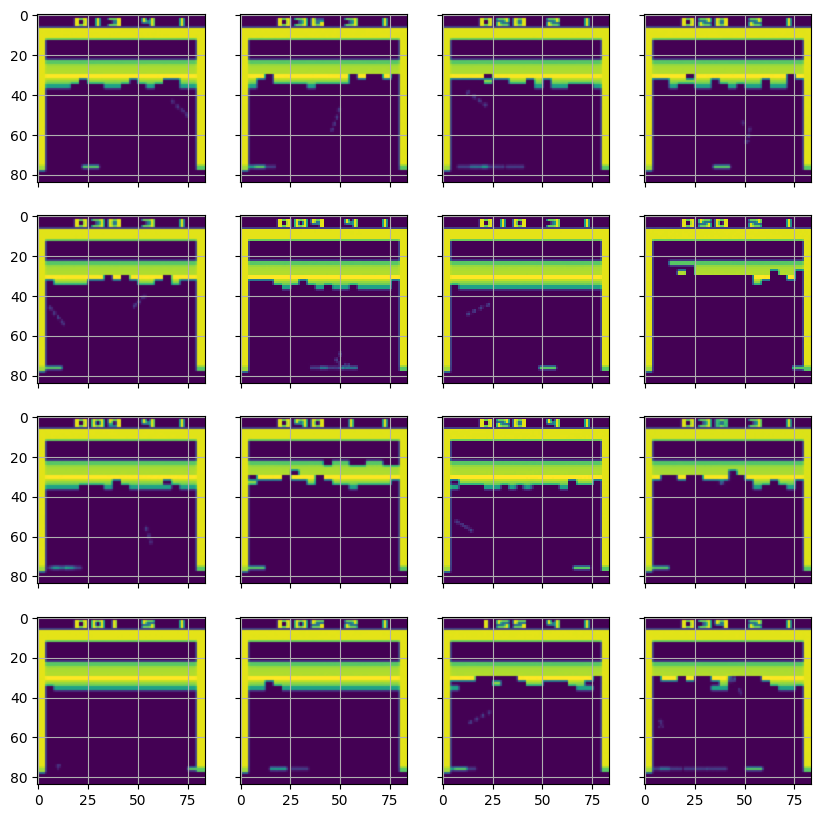

In [11]:
fig, axis = plt.subplots(4, 4, figsize=(10, 10), sharex=True, sharey=True)
for i in range(4):
    for j in range(4):
        axis[i, j].imshow(x[i * 4 + j].mean(dim=0).clip(0, 1))
        axis[i, j].grid(None)